# **STELLAR OBJECT CLASSIFICATION - Decision Trees, Random Forests, KNN, SVM, Gradient Boosting, AdaBoost & XGBoost**

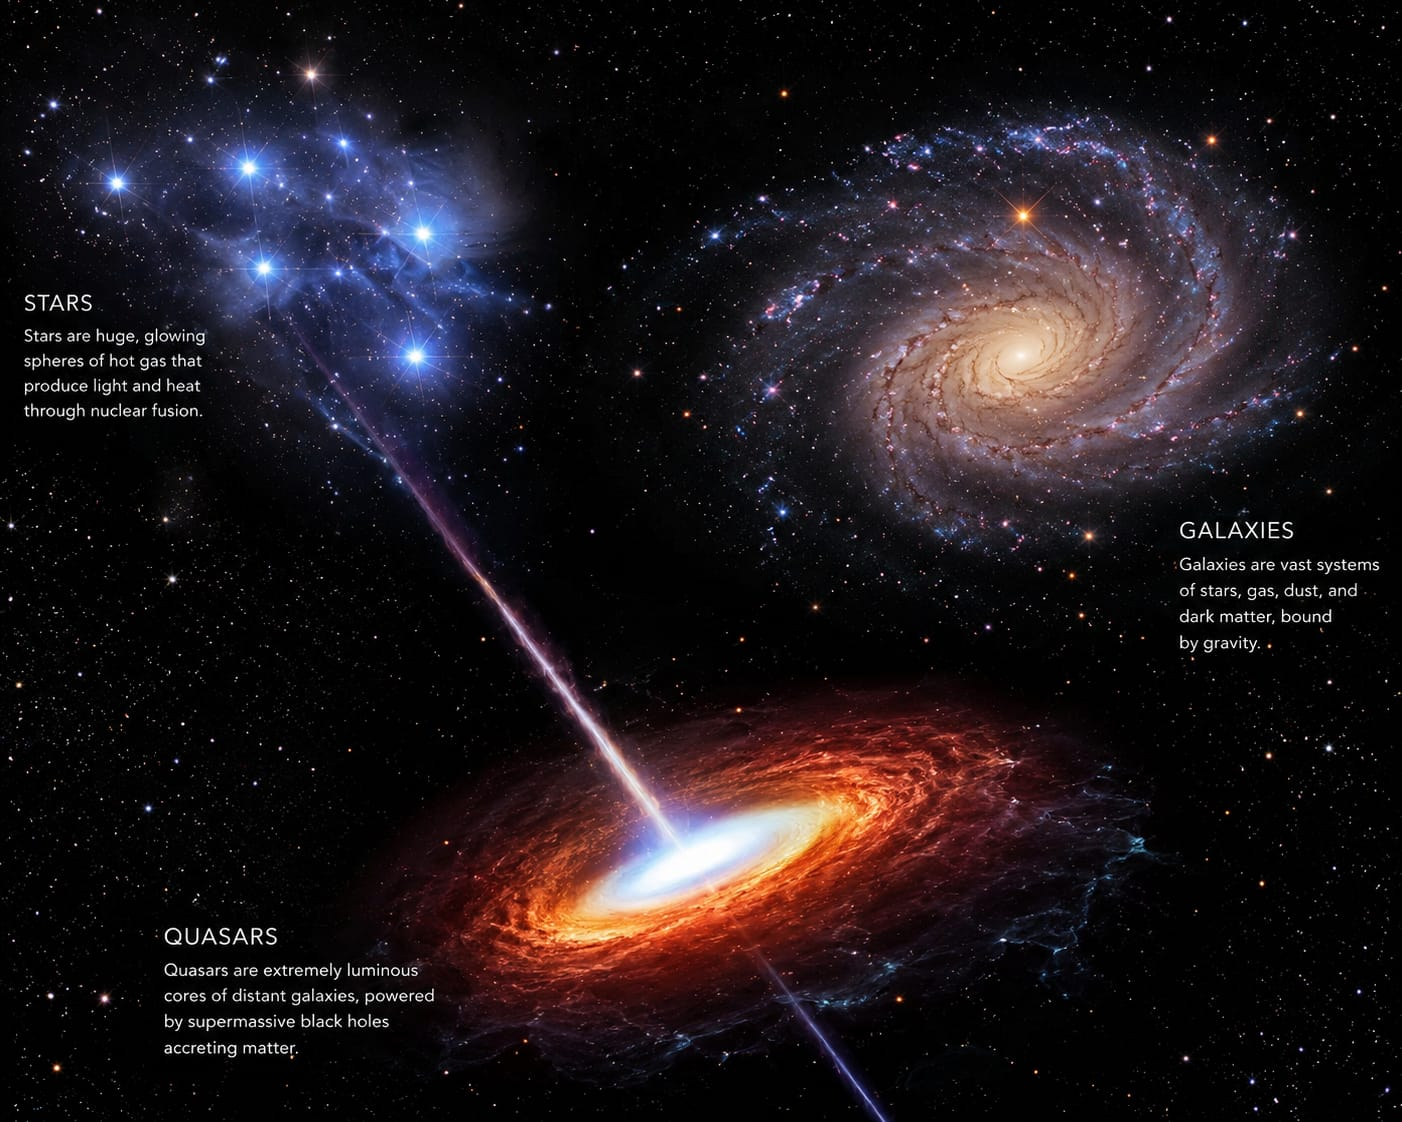

# **Table of Contents:**

1. [**Introduction**](#scrollTo=04uGboGMVdiS)
2. [**Preliminary Data Inspection** ](#scrollTo=N5pIhKp6-vr1)
    * [Import Libraries](#scrollTo=xshat2Cx-3vZ)
    * [Load Data](#scrollTo=StMllgblBWSE)
    * [Data Structure](#scrollTo=WIzchR9XBWdx)
    * [Data Preview](#scrollTo=WeJWRCVJBWn8)
    * [Missing Values & Data Types](#scrollTo=Aq4QrhRxB7bA)
    * [Outlier Detection](#scrollTo=9MYrcokMNUVC)
    * [Statistical Summary](#scrollTo=JC8kgztNCDe8)
    * [Class Frequency](#scrollTo=9AEATyKbCb1k)
    * [Class Frequency Graph](#scrollTo=YDnqJrVFCnCV)
    * [Inferences](#scrollTo=-JeFUTRkOeGw)
3. [**Exploratory Data Analysis**](#scrollTo=1RvWp3gbDQ0I)
     * [Frequency Distribution](#scrollTo=7AW9VQxnCnO7)
     * [Inferences](#scrollTo=gBkmnakpPcZP)
     * [Numerical Features by Object Class](#scrollTo=3ZOf1oSiDib0)
     * [Inferences](#scrollTo=2DEnn4zSQtk6)
     * [Sky Map](#scrollTo=wAtb_geDDinl)
     * [Inferences](#scrollTo=3TiIIw87Q95O)
     * [Correlation Heatmap](#scrollTo=bWpMXEEZDixm)
     * [Inferences](#scrollTo=tIxzbLgESDo7)
4. [**Data Preprocessing**](#scrollTo=ucKZxk-4FnoU)
     * [Drop Unnecessary Columns](#scrollTo=IwG-EVJfF2dX)
     * [Feature Engineering](#scrollTo=P0Tjna32F2Sb)
     * [Visualise Newly Created Columns](#scrollTo=5mWX1JSTjugs)
     * [Interpretation](#scrollTo=ZF4eizyPk40P)
     * [Input Features and Target Variable](#scrollTo=HBA-YBiSF2Ix)
     * [Label Encoding](#scrollTo=MQy-2_HHF19m)
     * [Class Mapping](#scrollTo=NyU-x-TZF1zb)
     * [Train-test Split](#scrollTo=B_lqQ4jmF1pi)
     * [Feature Scaling](#scrollTo=hCIXiIwuF1QA)
5. [**Model Training**](#scrollTo=zIo6wh39HsIG)
    *  [Training the Models](#scrollTo=l_4HFIVGHzXs)
6. [**Model Performance Evaluation**](#scrollTo=uk1qRcOYIqzu)
    * [Comparison Table](#scrollTo=6JPWnv45bgGt)
    * [Hyperparameter Tuning](#scrollTo=t7ZQhRttTRFY)
    * [Tuned vs Baseline Model](#scrollTo=Oor0b0CJVayu)
    * [Improvement over Baseline](#scrollTo=-AQ5lS-NVbAO)
7. [**Data Visualisation**](#scrollTo=8gm0R_roJOQk)
    *   [Comparison Graph of Evaluation Metrics](#scrollTo=xW_KcaHK49ih)
    * [Confusion Matrix](#scrollTo=19rYwqRwl6Qe)
8. [**Conclusion**](#scrollTo=7iX3fRBIl6u_)




# **Introduction**

**About:** This notebook implements a complete a Machine Learning workflow with the 'Stellar Classification - SDSS 17' dataset. This dataset consists of 100000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

**Models Used:** Decision Trees, Random Forests, K-Nearest Neighbours, Support Vector Machine, Gradient Boosting, AdaBoost and XGBoost.

**Objective:** Develop and identify a classification model that can accurately predict the class of new entities based on their astronomical features.

# **Preliminary Data Inspection**

In [46]:
# Import libraries for data handling, visualisation, preprocessing, model building and evaluation.
import numpy as np # Used for numerical caculations.
import pandas as pd # Used to load and work with datasets.
import matplotlib.pyplot as plt # Used to create graphs and charts.
import seaborn as sns # Used for advanced data visualisation.
# Import tools for data preprocessing.
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
# Import function to split data into training and testing sets.
from sklearn.model_selection import train_test_split
# Import pipeline to combine preprocessing and model training.
from sklearn.pipeline import Pipeline
# Import machine learning algorithms.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
# Install and import XGBoost classifier.
!pip install xgboost
from xgboost import XGBClassifier
# Import performance evaluation metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# Import tools for model tuning and cross-validation.
from sklearn.model_selection import GridSearchCV, cross_val_score
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [47]:
# Load the star claassification dataset into a DataFrame.
df = pd.read_csv("/content/star_classification(4).csv")

In [48]:
# Display the number of rows and columns in the dataset.
df.shape

(100000, 18)

In [49]:
# Display the first five rows to understand the dataset.
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [50]:
# Show information about each column, data types, and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [51]:
# Load dataset
df = pd.read_csv("/content/star_classification(4).csv")

# Select only numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect outliers using IQR
outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    outliers[col] = len(outlier_rows)

# Display number of outliers in each column
outlier_summary = pd.DataFrame({
    "Column": outliers.keys(),
    "Outlier Count": outliers.values()
})

print(outlier_summary)

         Column  Outlier Count
0        obj_ID              0
1         alpha              0
2         delta              0
3             u             56
4             g             99
5             r            132
6             i            198
7             z            320
8        run_ID              0
9      rerun_ID              0
10      cam_col              0
11     field_ID           5391
12  spec_obj_ID              0
13     redshift           8990
14        plate              0
15          MJD              0
16     fiber_ID              0


In [52]:
 # Display summary statistics such as mean, minimum, maximum, and standard deviation.
 df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [53]:
# Count how many records belong to each object class.
class_freq = df['class'].value_counts()
print(class_freq)

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


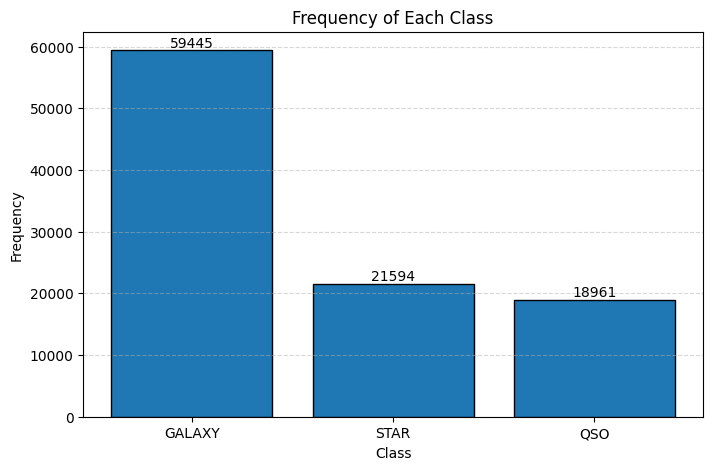

In [54]:
# Plot class frequency - create a figure with a specified size.
# Create a figure with a specified size.

plt.figure(figsize=(8,5))

# Create a bar chart showing the number of samples in each class.
plt.bar(class_freq.index, class_freq.values, edgecolor="black")

# Add chart title and axis labels.
plt.title("Frequency of Each Class")
plt.xlabel("Class")
plt.ylabel("Frequency")

# Add horizontal grid lines for better readability.
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Display the frequency value on top of each bar.
for i, values in enumerate(class_freq.values):
    plt.text(i, values, str(values), ha="center", va="bottom")

# Display the completed chart.
plt.show()

**What the Bar Chart shows:**


This is a bar chart showing how many objects belong to each class in your dataset.

**What it shows:**

There are three classes in the dataset:

Galaxy: 59,445 objects

Star: 21,594 objects

QSO (Quasar): 18,961 objects

The height of each bar represents the number of objects in that class. Taller bars mean there are more objects.

**Main observations:**

Galaxies are the most common class by a large margin.
Stars are the second most common class.
QSOs (Quasars) are the least common class, though their count is fairly close to the number of stars.

**Key takeaway:**

The dataset is not balanced because the classes do not have similar numbers of samples. Almost 60% of the data consists of galaxies, while stars and QSOs together make up the remaining 40%.

**Why this matters:**

Since galaxies are much more common, a machine learning model may become better at predicting galaxies than stars or QSOs. This is known as class imbalance, and it is something to keep in mind when training and evaluating the model.

# **Exploratory Data Analysis**

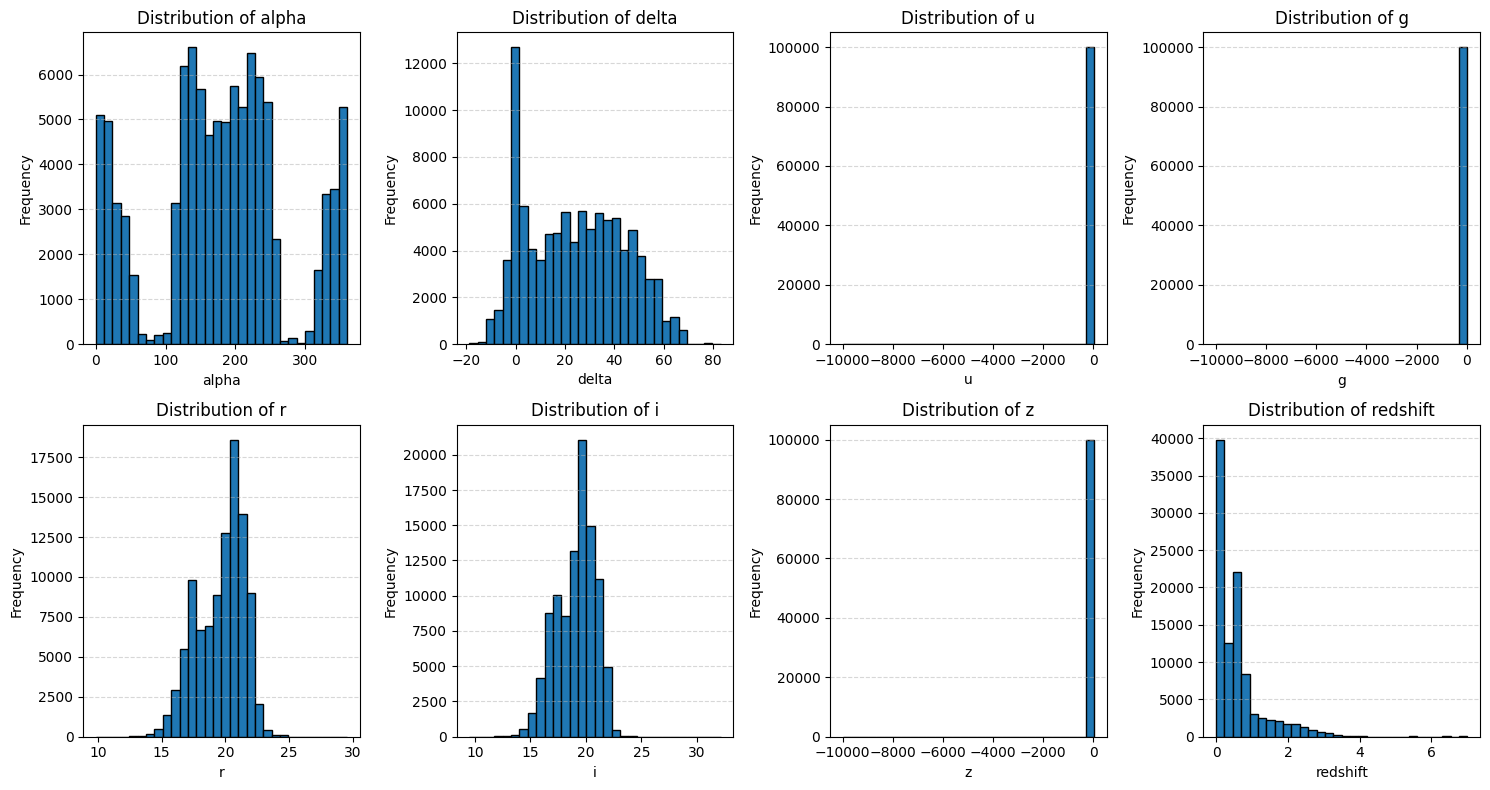

In [55]:
# Frequency Distribution of Numerical Features
# List the numerical columns to visualize.
columns = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

# Create a figure to display multiple histograms.
plt.figure(figsize=(15,8))

# Loop through each column and create a histogram.
for index, column in enumerate(columns, start=1):

    # Create a subplot for each feature.
    plt.subplot(2, 4, index)

    # Plot the distribution of values for the current feature.
    plt.hist(df[column].dropna(), bins=30, edgecolor="black")

    # Add chart title and axis labels.
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    # Add horizontal grid lines for better readability.
    plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust spacing between plots.
plt.tight_layout()

# Display all histograms.
plt.show()

**Interpretation:**

This figure contains histograms, which show how the values of each feature are distributed. Each bar represents how many data points fall within a certain range of values.

Here's a simple explanation of each plot:

1. **Alpha (Right Ascension):**
The values are spread across almost the entire range (0°–360°).
There are several peaks, meaning observations are more common in some regions of the sky than others. Takeaway: The observations are spread across different sky locations, but not evenly.

2. **Delta (Declination):**
Most values lie between 0° and 60°, with fewer observations at the extreme ends.
Takeaway: Most celestial objects in the dataset were observed in a specific region of the sky.
3. **u (Ultraviolet Magnitude):**
Nearly all values are concentrated in a narrow range.
A few extreme values stretch the x-axis, making the main distribution appear compressed.
Takeaway: Most objects have similar ultraviolet brightness, but there are a few unusual (outlier) values.
4. **g (Green Magnitude):**
Similar to the u feature.
Most observations are clustered together with a few extreme outliers.
Takeaway: The majority of objects have similar green-band brightness.
5. **r (Red Magnitude):**
Most values fall between 16 and 21, with a peak around 19–20.
The distribution is roughly bell-shaped.
Takeaway: Most objects have moderate brightness in the red band.
6. **i (Near-Infrared Magnitude):**
Similar to the r distribution.
Most values are concentrated around 18–20.
Takeaway: The near-infrared brightness of most objects is similar.
7. **z (Infrared Magnitude):**
Again, most values are clustered together with a few extreme outliers.
Takeaway: The infrared brightness values are concentrated within a narrow range.
8. **Redshift:**
Most values are close to 0.
The distribution has a long tail to the right, meaning only a few objects have very high redshift.
Takeaway: Most objects are relatively nearby, while only a small number are very distant.

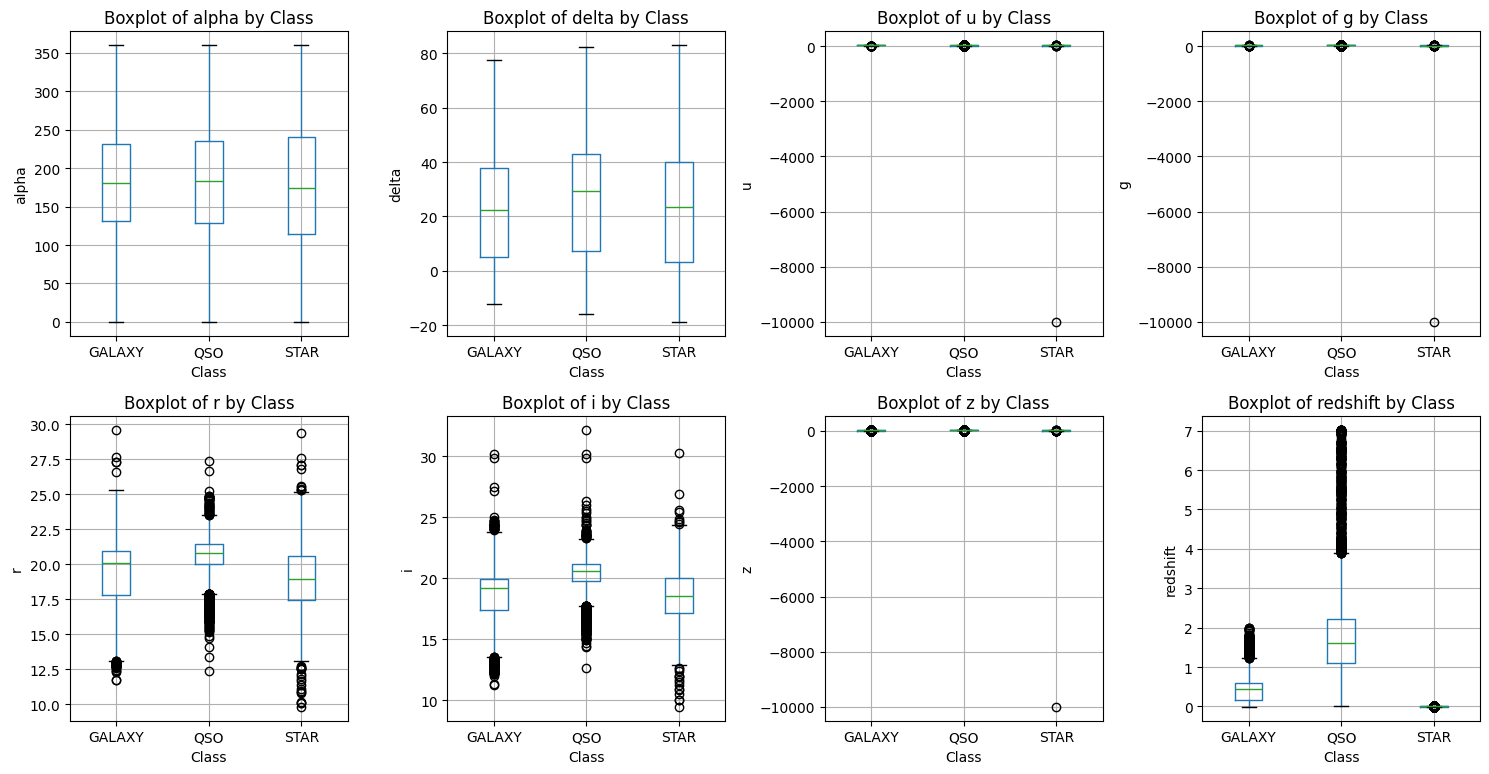

In [56]:
# Boxplots for Numerical Features by Class
# List the numerical features to compare across object classes.
features = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

# Create a figure for multiple boxplots.
plt.figure(figsize=(15,8))

# Loop through each feature and create a boxplot.
for index, feature in enumerate(features, start=1):

    # Create a subplot for the current feature.
    plt.subplot(2, 4, index)

    # Draw a boxplot grouped by object class.
    df.boxplot(column=feature, by="class", ax=plt.gca())

    # Add title and axis labels.
    plt.title(f"Boxplot of {feature} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(feature)

# Adjust spacing between plots.
plt.tight_layout()

# Display all boxplots.
plt.show()

**Interpretation:**

These are boxplots, which compare how each feature is distributed across the three classes (Galaxy, QSO, and Star).

**How to read a boxplot?**

Middle line inside the box: The median (middle value).

Box: Where the middle 50% of the data lies.

Whiskers: The normal range of values.

Dots outside the whiskers: Outliers (unusually high or low values).


1. **Alpha by Class:**
The boxplots for Galaxy, QSO, and Star look very similar.
All three classes cover almost the full range of alpha values. Takeaway:
Alpha (sky position) does not clearly distinguish between galaxies, stars, and QSOs.

2. **Delta by Class:**
The distributions are also very similar across all three classes.
QSOs have a slightly higher median than the other classes, but the difference is small. Takeaway:
Delta is not a strong feature for separating the classes.

3. **u (Ultraviolet Magnitude) by Class:**
Most values are grouped together.
There are extreme outliers, especially for the Star class (around -10000). Takeaway:
The majority of objects have similar u values, but there are some abnormal observations that may need preprocessing.

4. **g (Green Magnitude) by Class:**
Similar pattern to the u feature.
Most observations are clustered together.
A few extreme outliers are present.
Takeaway:
The feature is mostly consistent but contains some unusual values.

5. **r (Red Magnitude) by Class:**
QSOs have a slightly higher median than galaxies and stars.
There are many outliers in all three classes.
Takeaway:
The r feature shows some differences between classes, so it may help a model distinguish them.

6. **i (Near-Infrared Magnitude) by Class:**
Similar to the r feature.
QSOs generally have higher values.
Many outliers exist.
Takeaway:
The i feature also provides useful information for classification.

7. **z (Infrared Magnitude) by Class:**
Similar distributions for all classes.
Extreme outliers are visible, especially for stars.
Takeaway:
Most values are similar, but the presence of outliers should be considered.

8. **Redshift by Class:**
This is the most informative boxplot.
Stars: Very low redshift values clustered near zero.
Galaxies: Moderate redshift values.
QSOs: Much higher redshift values with many high-value outliers.
Takeaway:
Redshift clearly separates the three classes and is likely one of the most important features for classification.

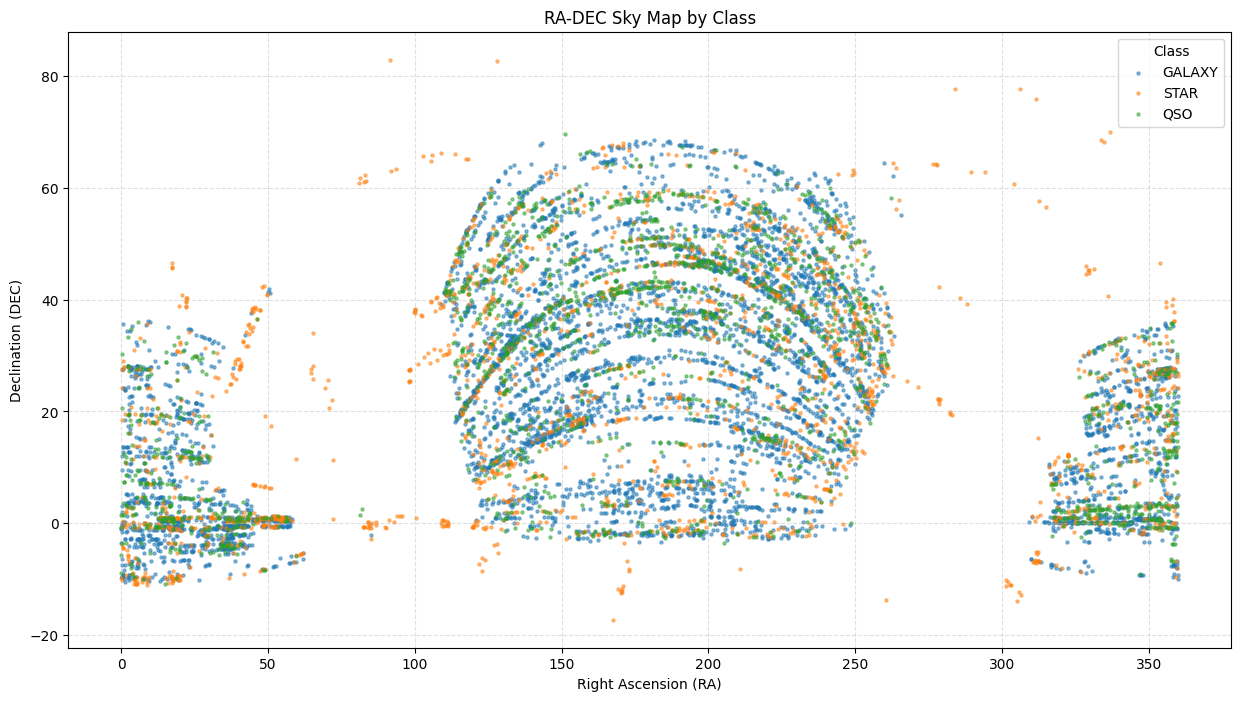

In [57]:
# Sky Map Visualisation
# Select a random sample of up to 10,000 records for faster plotting.
sky_df = df.sample(n=min(10000, len(df)), random_state=42)

# Create a figure for the scatter plot.
plt.figure(figsize=(15,8))

# Plot each object class with different points.
for class_name in sky_df["class"].unique():

    # Select data for the current class.
    class_data = sky_df[sky_df["class"] == class_name]

    # Plot Right Ascension (RA) against Declination (DEC).
    plt.scatter(
        class_data["alpha"],
        class_data["delta"],
        s=5,
        alpha=0.5,
        label=class_name
    )

# Add title, labels, legend, and grid.
plt.title("RA-DEC Sky Map by Class")
plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (DEC)")
plt.legend(title="Class")
plt.grid(True, linestyle="--", alpha=0.4)

# Display the scatter plot.
plt.show()

**Interpretation**

This is a scatter plot (sky map) showing where the celestial objects are located in the sky based on their coordinates.

**X-axis (RA – Right Ascension):** The object's position from left to right in the sky (0° to 360°).

**Y-axis (DEC – Declination):** The object's position from south to north in the sky.

**Each dot:** One object in the dataset.

**Different colors:** Represent the three classes (Galaxy, Star, and QSO).

**What it shows:**
The objects are not evenly spread across the sky.
Instead, they appear in distinct clusters and curved bands.
These bands are caused by the survey's observation pattern—the telescope only observed certain regions of the sky.

**Main observations:**
The largest concentration of objects is in the middle of the plot (RA roughly 120°–260°).
Smaller groups of observations appear near RA 0°–50° and RA 330°–360°.
The three classes (Galaxy, Star, and QSO) are mixed together in the same observed regions.
No class is confined to a unique area of the sky.

**Key takeaway:**

The sky map shows where the observations were made, not that galaxies, stars, or QSOs naturally occur only in those places. The clustering reflects the areas covered by the astronomical survey, rather than a separation between object types.

**Why this matters?**

RA and DEC describe an object's location, not its physical properties.
Since all three classes overlap heavily in these coordinates, RA and DEC alone are not good features for distinguishing between galaxies, stars, and QSOs.
Features such as redshift and the photometric magnitudes (u, g, r, i, z) are much more useful for classification.

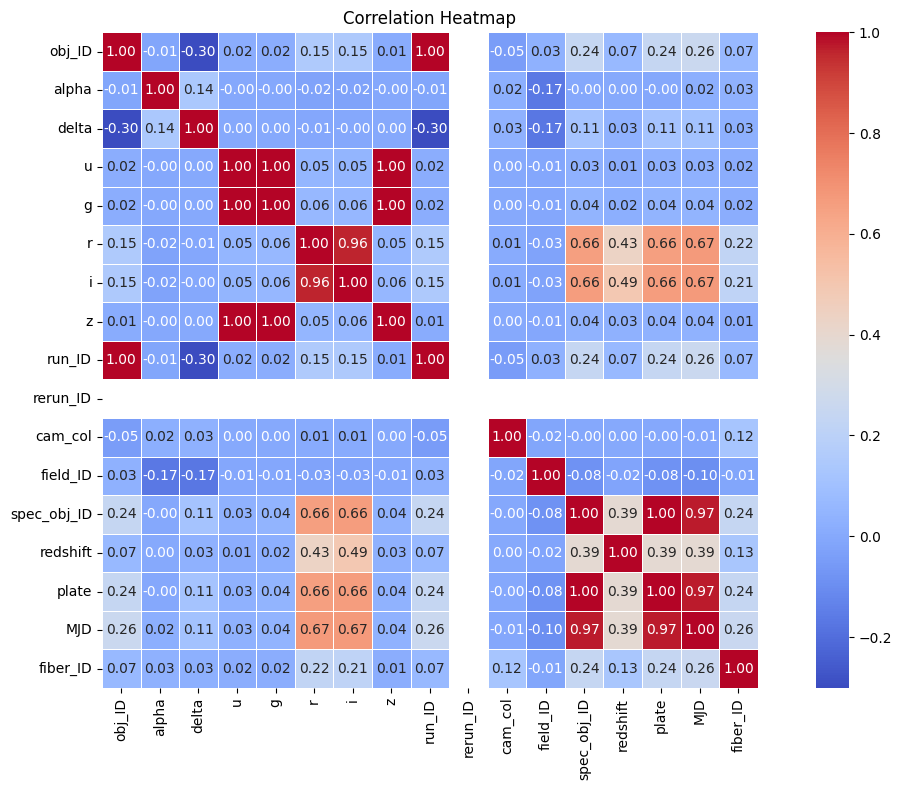

In [58]:
# Correlation Heatmap
# Select only numerical columns from the dataset.
numeric_df = df.select_dtypes(include=["number"])

# Calculate the correlation between numerical features.
correlation_matrix = numeric_df.corr()

# Create a figure for the heatmap.
plt.figure(figsize=(12,8))

# Display the correlation matrix as a heatmap.
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidth=0.5,
    square=True
)

# Add a title.
plt.title("Correlation Heatmap")

# Adjust layout and display the heatmap.
plt.tight_layout()
plt.show()

**Interpretation:**

This is a correlation heatmap, which shows how strongly different features are related to each other.

**How to read the heatmap?**

**Dark red (close to +1):** Strong positive correlation (both features increase together).

**Dark blue (close to -1):** Strong negative correlation (one increases while the other decreases).

**Light colors (close to 0):** Little or no relationship.

**A value of:**

**+1** = Perfect positive relationship.

**0** = No relationship.

**-1** = Perfect negative relationship.

**Main observations:**
1. **Strong correlation among u, g, and z:**
The u, g, and z features have correlations very close to 1.00.
This means they change together almost perfectly.
Takeaway:
These features contain very similar information and may be highly redundant.

2. **Strong correlation between r and i:**
r and i have a correlation of about 0.96.
Takeaway:
Objects that are bright in the r band tend to be bright in the i band as well.

3. **Redshift is moderately correlated with r and i:**
Redshift has a correlation of about 0.43–0.49 with r and i.
Takeaway:
As redshift increases, the values of these brightness features tend to change. This suggests they may help predict an object's class.

4. **Strong correlation among spec_obj_ID, plate, and MJD:**
spec_obj_ID and plate ≈ 1.00
plate and MJD ≈ 0.97.
Takeaway:
These are observation-related identifiers and naturally contain similar information.

5. **Alpha and Delta:**
Both have correlations close to 0 with most other variables.
Takeaway:
The sky position of an object is mostly independent of its brightness and redshift.

6. **obj_ID and run_ID:**
These two have a correlation close to 1.00.
Takeaway:
These are dataset identifiers rather than scientific measurements and are unlikely to improve classification.

**Overall interpretation:**

**The heatmap shows that:**

Several photometric features (u, g, z) are very strongly correlated, meaning they carry similar information.
r and i are also strongly related.
Redshift has a moderate relationship with some brightness features, making it useful for predicting object classes.
Identifier columns (obj_ID, run_ID, spec_obj_ID, plate, MJD) are highly correlated because they describe the observation process rather than the physical properties of the objects.
Alpha and Delta have very weak correlations with other features.

**Why this matters?**

**Correlation analysis helps identify:**

Redundant features, which may be removed to reduce model complexity.
Useful predictive features, such as redshift, r, and i.
Identifier columns that usually should not be used as model inputs because they do not represent meaningful physical characteristics.

# **Data Preprocessing**

In [59]:
# Drop Unnecessary Columns
# List the columns that are not useful for prediction.
id_columns = [
    "obj_ID", "run_ID", "rerun_ID", "cam_col",
    "field_ID", "plate", "MJD", "fiber_ID"
]

# Remove the unnecessary columns from the dataset.
df = df.drop(columns=id_columns)

In [60]:
# Feature Engineering
# Create new features by calculating the difference between different photometric bands.
# These color index features help improve the model's ability to distinguish
# between stars, galaxies, and quasars.

# Difference between the u and g bands.
df['u_g'] = df['u'] - df['g']

# Difference between the g and r bands.
df['g_r'] = df['g'] - df['r']

# Difference between the r and i bands.
df['r_i'] = df['r'] - df['i']

# Difference between the i and z bands.
df['i_z'] = df['i'] - df['z']

# Difference between the u and r bands.
df['u_r'] = df['u'] - df['r']

# Difference between the g and i bands.
df['g_i'] = df['g'] - df['i']

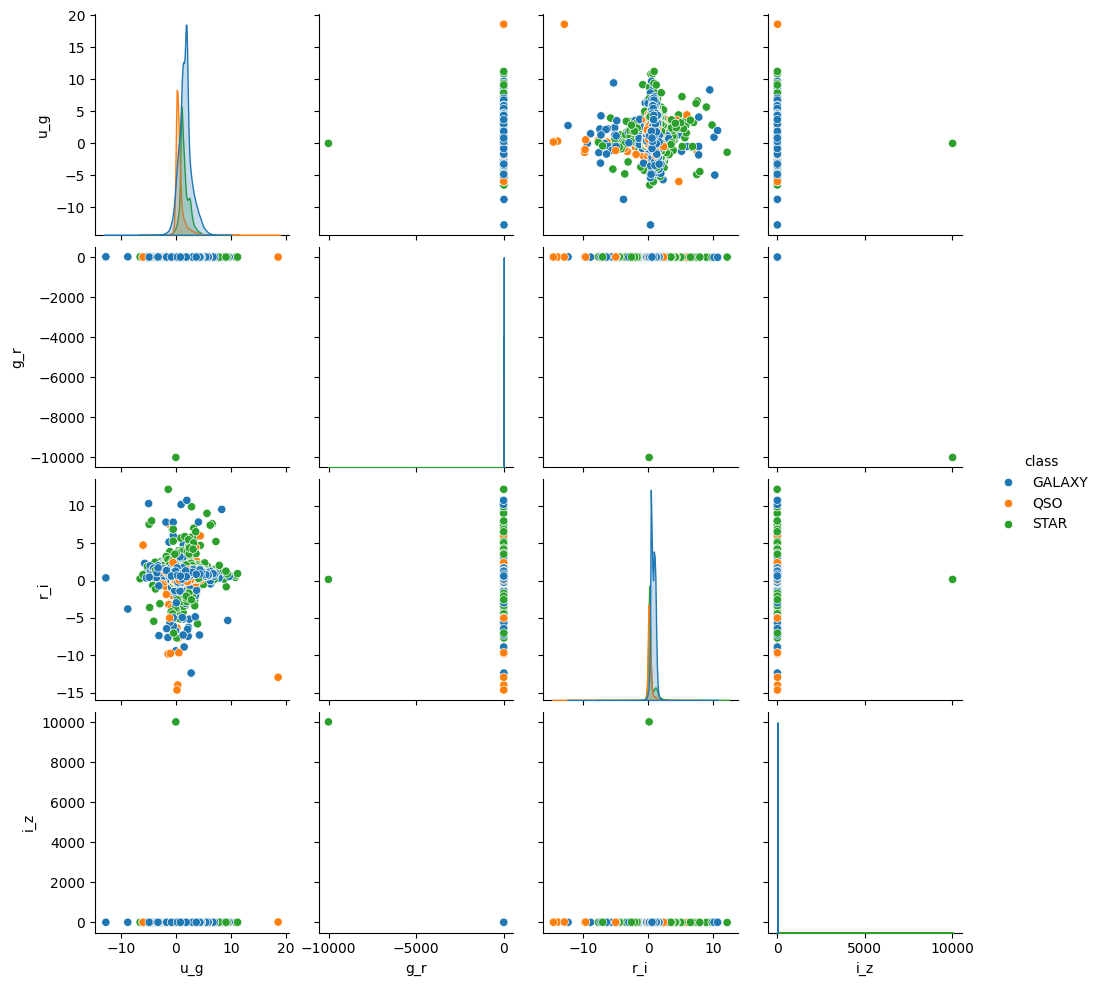

In [61]:
# Select the engineered colour index features to compare
colors = ["u_g", "g_r", "r_i", "i_z"]

# Create a pair plot to visualize pairwise relationships between
# the colour indices. Points are coloured by object class
# (STAR, GALAXY, or QSO), while the diagonal shows the distribution
# of each colour index using Kernel Density Estimation (KDE).
sns.pairplot(
    df[colors + ["class"]],
    hue="class",
    diag_kind="kde"
)

**Inference from the Pairplot**

The pairplot compares the color index features (u_g, g_r, r_i, and i_z) for the three object classes: Galaxy, QSO, and Star.

**Interpretation:**


* The distributions of all three classes overlap considerably across all four color indices, indicating that no single feature can effectively distinguish between galaxies, QSOs, and stars.

* The scatter plots show that most observations are concentrated near the center, with no clearly separated clusters, suggesting that a combination of multiple features will be required for accurate classification.

* The u_g and r_i color indices exhibit slightly greater variation among the classes, but the overlap remains substantial.

* The g_r and i_z features contain extreme outliers (values around ±10,000), which are unrealistic for color indices and likely represent missing values, measurement errors, or data-entry issues.

* These outliers dominate the plot scales, making it difficult to observe the true distribution of the majority of the data. Therefore, data cleaning and outlier treatment are necessary before model development.

**Overall Conclusion:**

The pairplot indicates that the photometric color indices alone provide only moderate discrimination between the three astronomical object classes. Since the classes overlap significantly, classification models should rely on the combined information from multiple features rather than any single color index. Additionally, preprocessing steps such as handling outliers and invalid values are essential to improve data quality and model performance.

In [62]:
# Separate the dataset into input features (X) and target variable (y).

# X contains all the predictor columns.
X = df.drop(columns="class")

# y contains the class labels to be predicted.
y = df["class"]

In [63]:
# Convert the class names into numerical values for machine learning models.

label_encoder = LabelEncoder()

# Transform the class labels into numbers.
y = label_encoder.fit_transform(y)

In [64]:
# Create a dictionary that shows the original class names
# and their corresponding numerical labels.

class_mapping = dict(
    zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_))
)

# Display the mapping.
print(class_mapping)

{'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [65]:
# Split the dataset into training and testing sets.

# 80% of the data is used for training.
# 20% of the data is used for testing.
# random_state ensures the same split every time.
# stratify keeps the class distribution balanced.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
import numpy as np

print("Before SMOTE:")
classes, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")

Before SMOTE:
Class 0: 47556
Class 1: 15169
Class 2: 17275


In [67]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [68]:
print("After SMOTE:")
classes, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")

After SMOTE:
Class 0: 47556
Class 1: 47556
Class 2: 47556


In [69]:
# Create a pipeline for the K-Nearest Neighbors model.
# StandardScaler scales the feature values before training.

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Create a pipeline for the Support Vector Machine model.
# Feature scaling improves SVM performance.

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

# **Model Training**

In [70]:
# Create and train different machine learning classification models
# using the training dataset. These trained models will later be
# evaluated to identify the best performing model.

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# **Model Performance Evaluation**

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Dictionary of trained models
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Gradient Boosting": gb_model,
    "AdaBoost": ada_model,
    "XGBoost": xgb_model
}

# Store evaluation results
comparison_results = []

for name, model in models.items():

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    comparison_results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })

# Create comparison table
comparison_df = pd.DataFrame(comparison_results)

# Sort by Accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

# Reset index
comparison_df.reset_index(drop=True, inplace=True)

print("Comparative Performance of Classification Algorithms")
display(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Comparative Performance of Classification Algorithms


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.9806,0.9805,0.9806,0.9805
1,Random Forest,0.9795,0.9794,0.9795,0.9794
2,Gradient Boosting,0.9792,0.9791,0.9792,0.9791
3,Decision Tree,0.9686,0.9685,0.9686,0.9685
4,AdaBoost,0.9307,0.9316,0.9307,0.9310
5,K-Nearest Neighbors,0.7016,0.6936,0.7016,0.6853
6,Support Vector Machine,0.5943,0.4225,0.5943,0.4447


In [72]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

# Create model
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

# Test Accuracy
y_pred = best_xgb.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

Best Cross Validation Accuracy:
0.9789249967121229

Test Accuracy: 0.98015

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11889
           1       0.97      0.94      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [73]:
from xgboost import XGBClassifier

# Baseline model
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Train baseline model
xgb.fit(X_train, y_train)

# Predictions
baseline_pred = xgb.predict(X_test)
tuned_pred = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ---------------------------
# Baseline Model Predictions
# ---------------------------
baseline_pred = xgb.predict(X_test)

# ---------------------------
# Tuned Model Predictions
# ---------------------------
tuned_pred = best_xgb.predict(X_test)

# ---------------------------
# Performance Comparison
# ---------------------------
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline XGBoost": [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred, average='weighted'),
        recall_score(y_test, baseline_pred, average='weighted'),
        f1_score(y_test, baseline_pred, average='weighted')
    ],
    "Tuned XGBoost": [
        accuracy_score(y_test, tuned_pred),
        precision_score(y_test, tuned_pred, average='weighted'),
        recall_score(y_test, tuned_pred, average='weighted'),
        f1_score(y_test, tuned_pred, average='weighted')
    ]
})

print(comparison)

      Metric  Baseline XGBoost  Tuned XGBoost
0   Accuracy          0.980550       0.980150
1  Precision          0.980475       0.980075
2     Recall          0.980550       0.980150
3   F1-Score          0.980463       0.980057


In [74]:
comparison["Improvement"] = (
    comparison["Tuned XGBoost"] - comparison["Baseline XGBoost"]
)

print(comparison)

      Metric  Baseline XGBoost  Tuned XGBoost  Improvement
0   Accuracy          0.980550       0.980150    -0.000400
1  Precision          0.980475       0.980075    -0.000401
2     Recall          0.980550       0.980150    -0.000400
3   F1-Score          0.980463       0.980057    -0.000406


In [75]:
print("Best CV Accuracy:", grid_search.best_score_)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, best_xgb.predict(X_test)))

Best CV Accuracy: 0.9789249967121229
Test Accuracy: 0.98015


# **Data Visualisation**

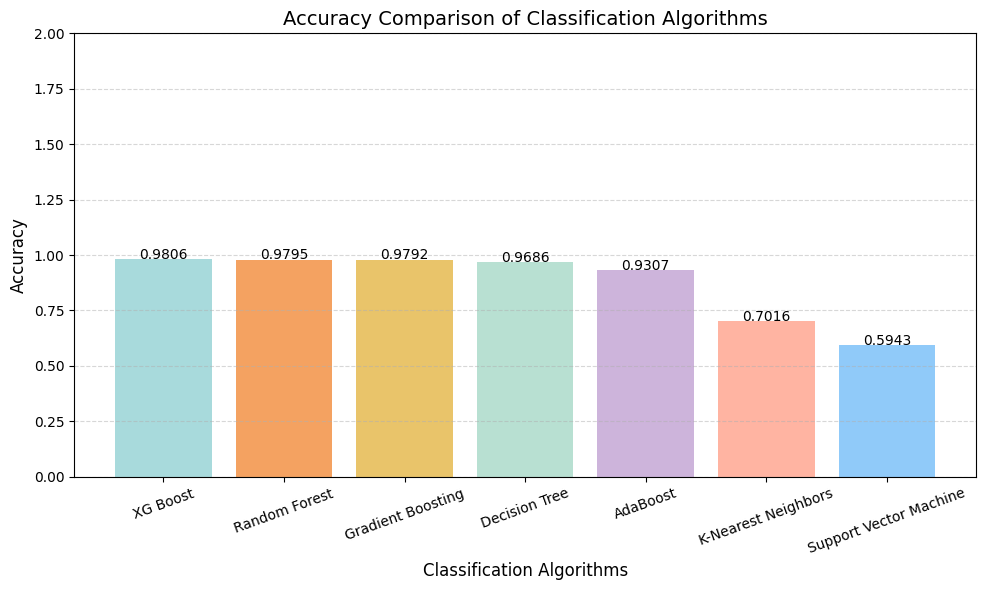

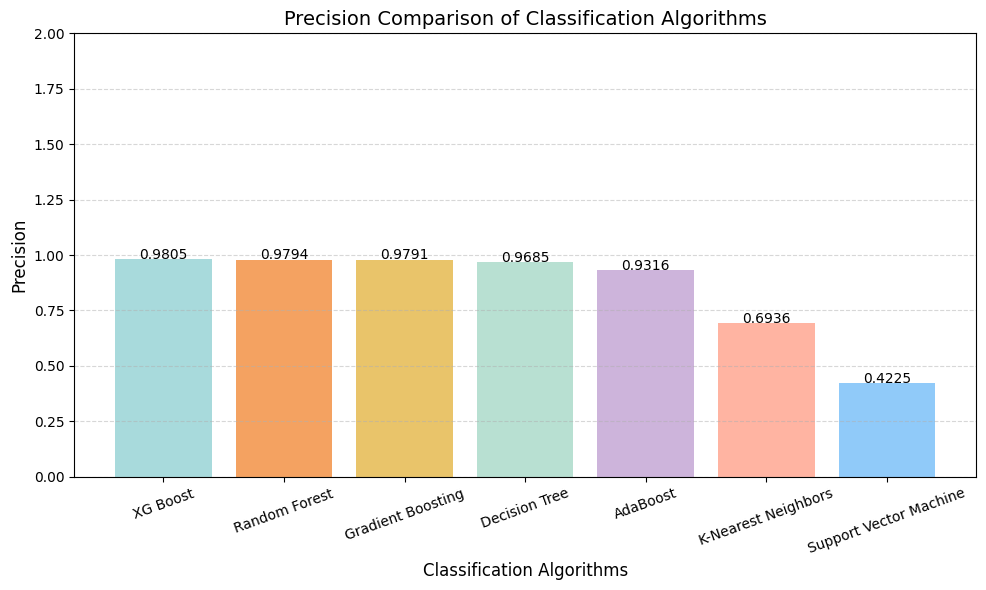

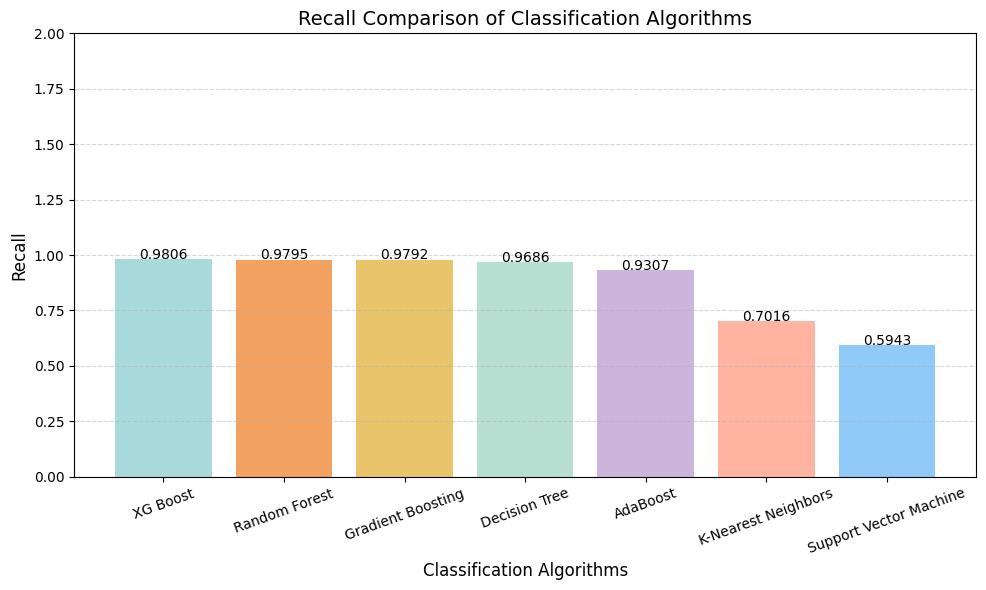

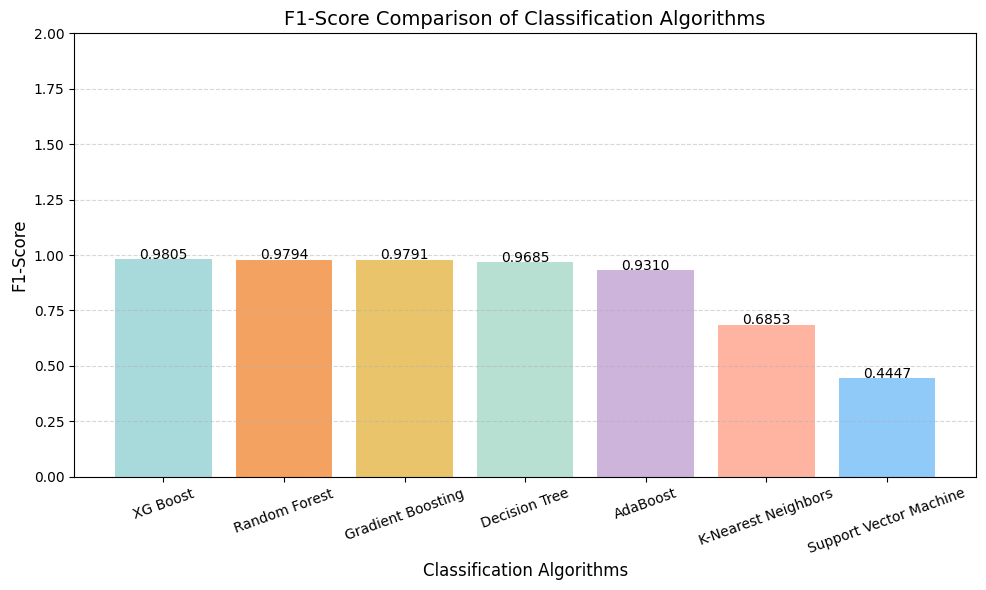

In [76]:
# Classification algorithms used in the project
algorithms = [
    'XG Boost',
    'Random Forest',
    'Gradient Boosting',
    'Decision Tree',
    'AdaBoost',
    'K-Nearest Neighbors',
    'Support Vector Machine'
]

# Colors for each algorithm
colors = [ "#A8DADC",
    "#F4A261",
    "#E9C46A",
    "#B8E0D2",
    "#CDB4DB",
    "#FFB4A2",
    "#90CAF9"]

# Function to plot a comparison graph for any evaluation metric
def plot_metric(metric_values, metric_name):
    """
    Plots a bar chart comparing the performance of
    classification algorithms for a given metric.
    """

    plt.figure(figsize=(10, 6))

    # Create bar chart
    bars = plt.bar(algorithms, metric_values, color=colors)

    # Display metric value on top of each bar
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}',
                 ha='center', fontsize=10)

    # Chart title and labels
    plt.title(f'{metric_name} Comparison of Classification Algorithms', fontsize=14)
    plt.xlabel('Classification Algorithms', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)

    # Formatting
    plt.ylim(0, 2.00)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


# Actual evaluation metrics from the project
accuracy =  [0.9806, 0.9795, 0.9792, 0.9686, 0.9307, 0.7016, 0.5943]

precision = [0.9805, 0.9794, 0.9791, 0.9685, 0.9316, 0.6936, 0.4225]

recall =    [0.9806, 0.9795, 0.9792, 0.9686, 0.9307, 0.7016, 0.5943]

f1_score =  [0.9805, 0.9794, 0.9791, 0.9685, 0.931, 0.6853, 0.4447]

# Generate graphs
plot_metric(accuracy, 'Accuracy')
plot_metric(precision, 'Precision')
plot_metric(recall, 'Recall')
plot_metric(f1_score, 'F1-Score')

<Figure size 600x500 with 0 Axes>

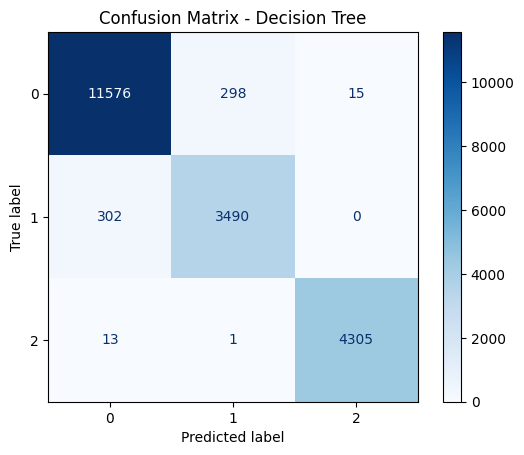

<Figure size 600x500 with 0 Axes>

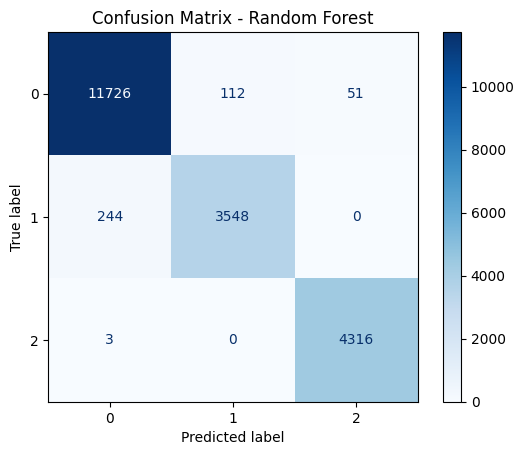

<Figure size 600x500 with 0 Axes>

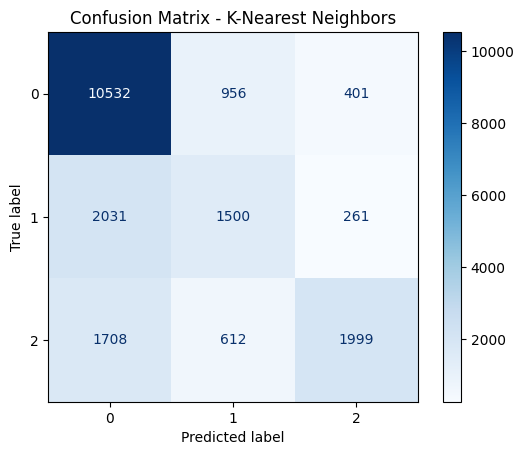

<Figure size 600x500 with 0 Axes>

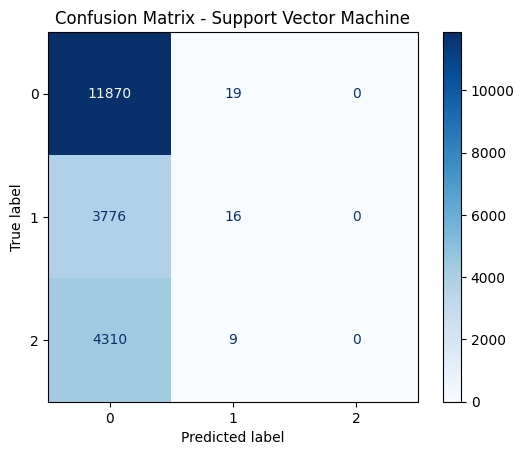

<Figure size 600x500 with 0 Axes>

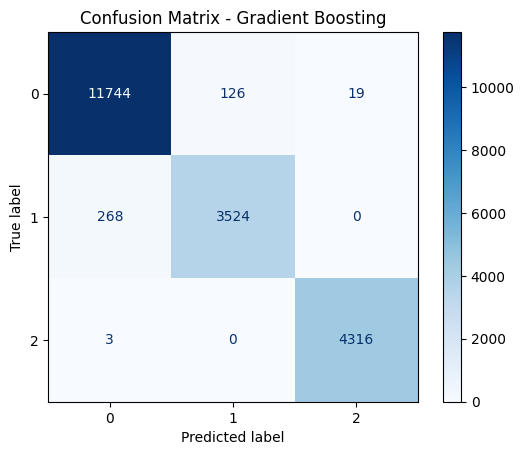

<Figure size 600x500 with 0 Axes>

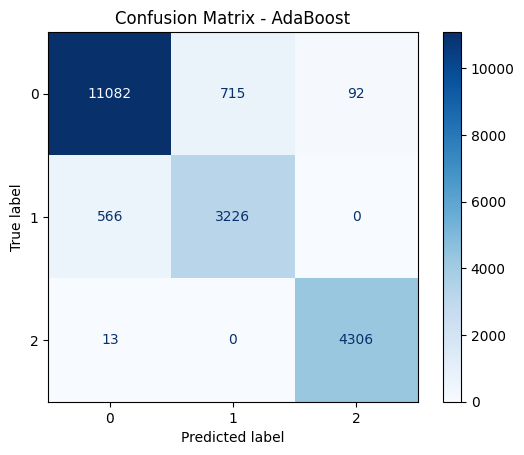

<Figure size 600x500 with 0 Axes>

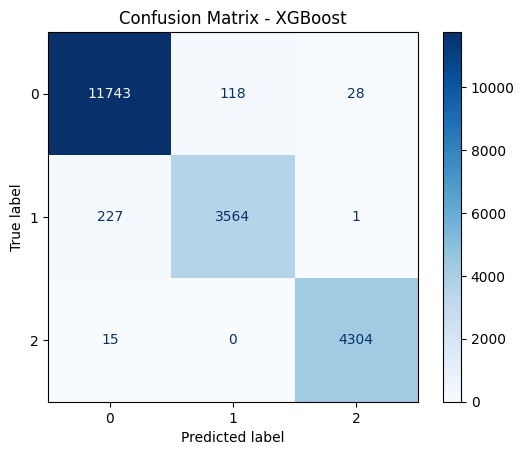

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dictionary containing all trained models
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Gradient Boosting": gb_model,
    "AdaBoost": ada_model,
    "XGBoost": xgb_model
}

# Plot confusion matrix for each model
for model_name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()

# **Conclusion**

This project successfully developed a machine learning model to classify celestial objects into stars, galaxies, and quasars using astronomical observation data. The dataset was cleaned, explored, and analyzed to understand the relationships between different photometric and spectral features. Several classification algorithms, including Decision Tree, Random Forest, K-Nearest Neighbors, Support Vector Machine, Gradient Boosting, AdaBoost, and XGBoost, were trained and evaluated. Among these models, XGBoost achieved the best overall performance, with a test accuracy of approximately 98%, demonstrating its ability to accurately distinguish between the three classes of celestial objects. Hyperparameter tuning further confirmed the model's robustness, although the baseline XGBoost model already provided excellent results. Overall, the project shows that machine learning techniques can effectively automate the classification of astronomical objects, reducing the need for manual analysis and supporting large-scale astronomical surveys. The high accuracy achieved indicates that the selected features contain strong predictive information and that the developed model can serve as a reliable tool for stellar object classification.